In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
df=pd.read_csv("Walmart.csv")
df.head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12-03-2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,02-04-2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,09-04-2010,1545418.53,0,65.86,2.770,210.622857,7.808


In [5]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [6]:
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [7]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [18]:
df.dtypes

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
Year                     int32
Month                    int32
Quarter                  int32
Week                    UInt32
Day                      int32
Day_Name                object
dtype: object

In [13]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Date']

0      2010-02-05
1      2010-02-12
2      2010-02-19
3      2010-02-26
4      2010-03-05
          ...    
6430   2012-09-28
6431   2012-10-05
6432   2012-10-12
6433   2012-10-19
6434   2012-10-26
Name: Date, Length: 6435, dtype: datetime64[ns]

In [15]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day
df['Day_Name'] = df['Date'].dt.day_name()
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Quarter,Week,Day,Day_Name
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,1,5,5,Friday
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,1,6,12,Friday
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,1,7,19,Friday
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,1,8,26,Friday
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,1,9,5,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,3,39,28,Friday
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012,10,4,40,5,Friday
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012,10,4,41,12,Friday
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,4,42,19,Friday


Exploratory Data Analysis

In [19]:
df['Weekly_Sales'].describe()

count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64

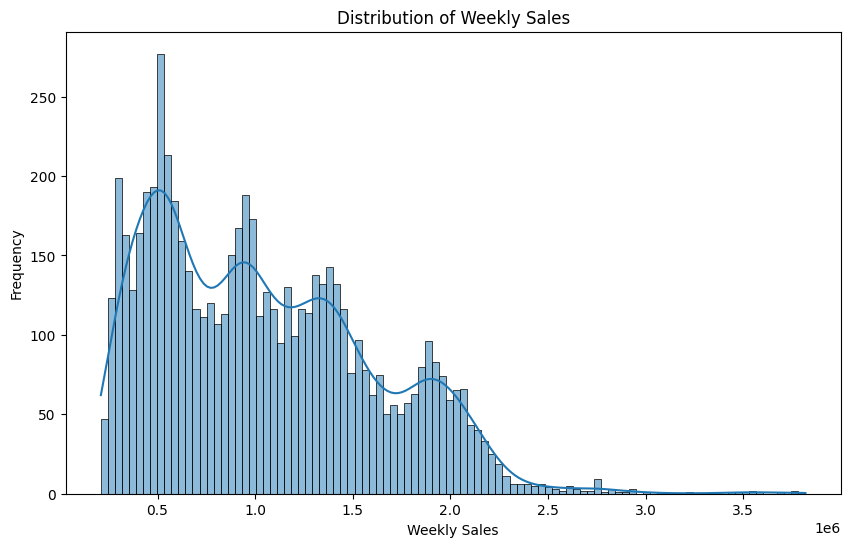

In [20]:
# Distribution of Weekly Sales

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Weekly_Sales',
    bins=100,
    kde=True
)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

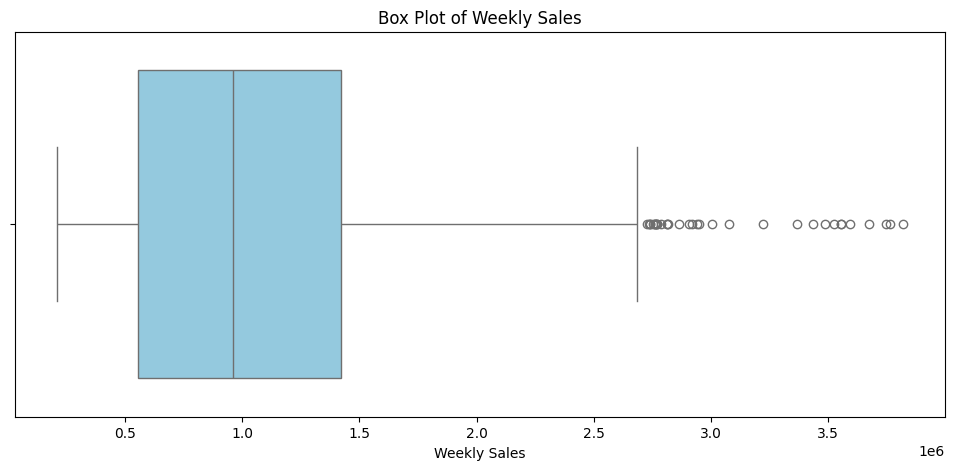

In [22]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df['Weekly_Sales'], color='skyblue')
plt.title("Box Plot of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.show()

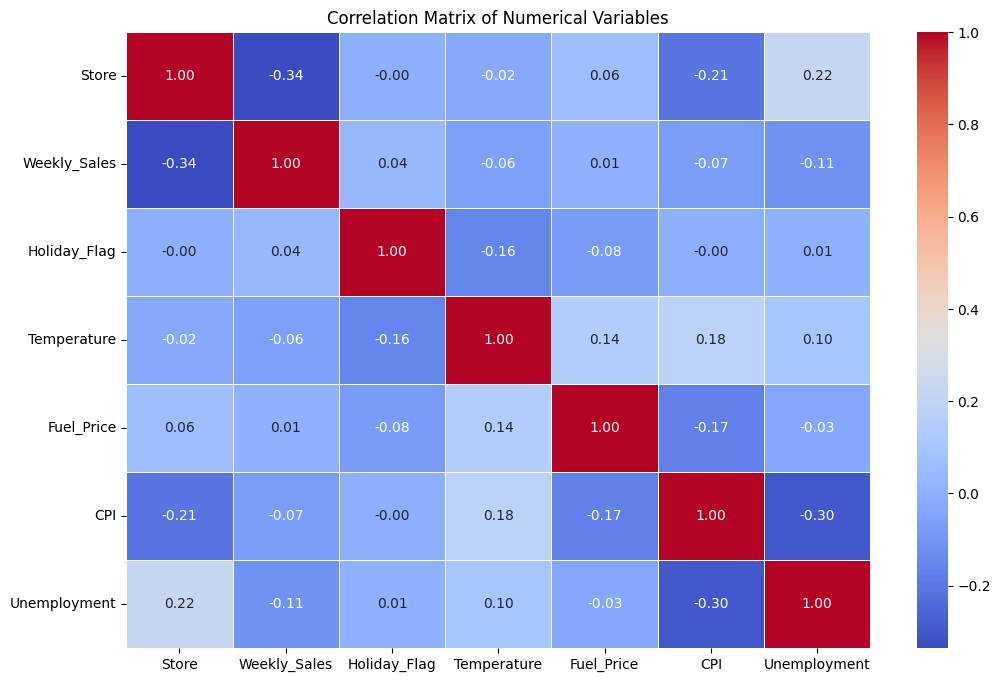

In [25]:
# Correlation with numerical columns 
numerical_columns = df.select_dtypes(include=['int64', 'float64'])
numerical_columns.head()
correlation_matrix = numerical_columns.corr()
correlation_matrix
plt.figure(figsize=(12,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [ ]:
# Analyze skewness and kurtosis.
skewness = df.select_dtypes(include=['int64', 'float64']).skew()
print(skewness.sort_values(ascending=False))

Holiday_Flag    3.373499
Unemployment    1.188144
Weekly_Sales    0.668362
CPI             0.063492
Store           0.000000
Fuel_Price     -0.096158
Temperature    -0.336768
dtype: float64


In [ ]:
kurtosis = df.select_dtypes(include=['int64', 'float64']).kurt()
print(kurtosis.sort_values(ascending=False))

Holiday_Flag    9.383410
Unemployment    2.639712
Weekly_Sales    0.053141
Temperature    -0.612801
Fuel_Price     -1.177378
Store          -1.201187
CPI            -1.839813
dtype: float64
